In [60]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
results_path_npe_c = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/npe_c/"
results_path_tsnpe = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/tsnpe/"
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_names_to_nice = {"npe_c": "SNPE-C",
                                  "tsnpe": "TSNPE",
                                  "nle_mcmc": "SNLE-MCMC",
                                  "nle_vi": "SNLE-VI",
                                  "nre": "SNRE-B"}
algorithm_KLs_squared_norms_ID = {"npe_c": 0,
                                  "tsnpe": 0,
                                  "nle_mcmc": 0,
                                  "nle_vi": 0,
                                  "nre": 1} # The ID of the experiment in each algorithm directory

In [61]:
KLs_dicts = {}
KLs_squared_norms_configs = {}

for algorithm_name in algorithm_names:
    KLs_squared_norms_ID = algorithm_KLs_squared_norms_ID[algorithm_name]

    results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
    config_path = results_path + f"KLs_squared_norms{KLs_squared_norms_ID}.yaml"
    KLs_path = results_path + f"KLs_squared_norms{KLs_squared_norms_ID}_KLs_dict.npz"

    # Load config
    with open(config_path, "r") as f:
        KLs_squared_norms_config = yaml.safe_load(f)
    KLs_squared_norms_configs[algorithm_name] = KLs_squared_norms_config

    # Load squared norms
    KLs_dict = dict(np.load(KLs_path))
    KLs_dicts[algorithm_name] = KLs_dict

In [62]:
def plot_KL_across_rounds(KLs_dicts, exclude_rounds=None, exclude_methods=None, title=None):
    if exclude_rounds is None:
        exclude_rounds = []
    if exclude_methods is None:
        exclude_methods = []

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel("Round")
    ax.set_ylabel(r"$KL\left(\tilde{\pi} || \pi\right)$")
    if title is None:
        ax.set_title("KL divergence between approximate posterior and true posterior at each round")
    else:
        ax.set_title(title)

    global_rs = set()

    # Loop over algorithms
    for method_name, KLs_dict in KLs_dicts.items():
        if method_name not in exclude_methods:
            rs = []
            mean_KLs = []
            SEs = []
            r = 0
            while f"round_{r}" in KLs_dict:
                if r not in exclude_rounds:

                    KLs = np.asarray(KLs_dict[f"round_{r}"])

                    # Handle scalar or single repetition safely
                    if KLs.ndim == 0:
                        KLs = KLs[np.newaxis]

                    R = len(KLs)

                    mean_KLs.append(np.mean(KLs))

                    if R > 1:
                        SEs.append(np.std(KLs, ddof=1) / np.sqrt(R))
                    else:
                        SEs.append(0.0)

                    rs.append(r)
                    global_rs.add(r)

                r += 1

            rs = np.array(rs) + 1
            mean_KLs = np.array(mean_KLs)
            SEs = np.array(SEs)

            # Plot mean line
            line, = ax.plot(rs, mean_KLs, label=r"Mean KL $\pm 2 \text{SE}$ for " + f"{algorithm_names_to_nice[method_name]}")

            # Shaded +-1 SE band
            ax.fill_between(
                rs,
                mean_KLs - 2 * SEs,
                mean_KLs + 2 * SEs,
                alpha=0.2,
                color=line.get_color(),
            )

    # For xticks
    global_rs = list(global_rs)
    global_rs = np.array(global_rs) + 1 # Start index from round 1 not round 0
    ax.set_xticks(global_rs)

    ax.legend()
    plt.tight_layout()
    plt.show()


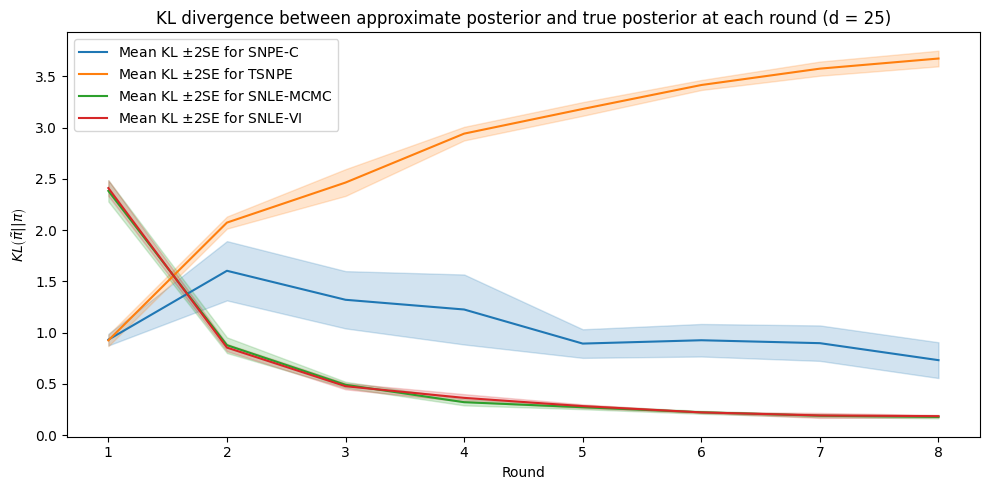

In [66]:
d = KLs_squared_norms_configs["npe_c"]["d"] # Assume d is the same for all experiments (it must be!)
title = f"KL divergence between approximate posterior and true posterior at each round (d = {d})"
plot_KL_across_rounds(KLs_dicts, exclude_methods=["nre"], title=title) # Exclude NRE since its poor

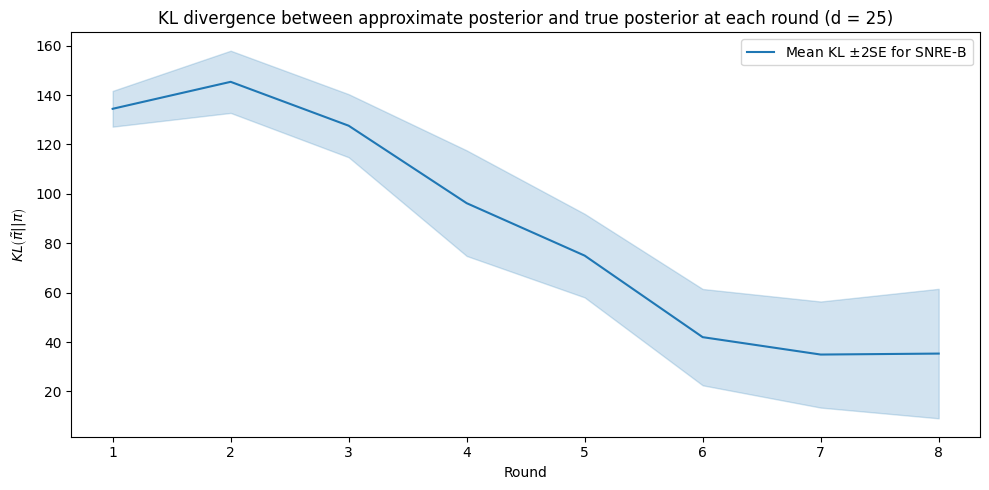

In [67]:
d = KLs_squared_norms_configs["npe_c"]["d"] # Assume d is the same for all experiments (it must be!)
title = f"KL divergence between approximate posterior and true posterior at each round (d = {d})"
plot_KL_across_rounds(KLs_dicts, exclude_methods=["npe_c", "tsnpe", "nle_mcmc", "nle_vi"], title=title) # Exclude NRE since its poor